<a href="https://colab.research.google.com/github/ChenOnline/APEX_WVC/blob/main/Hypothesis_Testing_2Proportions_WVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STATS Module: Hypothesis Testing for Comparing 2 Population Proportions

Module adpated from SJSU APEX, David Schuster. Data set from Ken Brown.

Licensed under CC BY-NC-SA

## Part II. Background

We are now ready for the conceptual jump to inferential statistics. In inferential statistics, we use properties of one sample distribution (called sample statistics) to make inferences about population distributions.

The following background is recommended before starting this module:

1. **Other hypothesis testing material in your course** This module will work best if you have some familiarity with hypothesis testing in your course, even just the basics. You may want to review your notes or textbook before starting this module.

2. **Welcome to Colab** If you have not worked through the <a href="https://colab.research.google.com/drive/1zTk_n6BL8Tvdhaufq_FYNXK0dbvGKnxX?usp=sharing">Welcome to Colab</a> notebook yet, you should do that first.

### Learning Outcomes

These exercises map onto several learning objective(s) for the C-ID descriptor for [Introduction to Statistics](https://c-id.net/descriptors/final/show/365). Upon successful completion of the course, you will be able to:  

* LO 2: Apply concepts of sample space and probability

* LO 9: Determine and interpret levels of statistical significance including p-values;

* LO 10: Interpret the output of a technology-based statistical analysis

* LO 11: Identify the basic concept of hypothesis testing including Type I and II errors

* LO 12: Formulate hypothesis tests involving samples from one and two populations

Next, read through the activity and follow the steps indicated by the arrows.



## Part III. Activity

This activity will use a set of data collected from flights from the San Francisco Bay Area (SFO, OAK and SJC) to Seattle, Washington in 2014.


Set up this activity by running the code block below. This will import the data. Reminder: to run the cell, you can either use `Shift` + `Enter`, or you can hit the play button.

### 1. Get Data

Before you can begin these exercises, you need to run the code cell below, which will import the data file and create a dataframe (i.e., spreadsheet) named `data`. After you run the cell, you will proceed to the next section to preview the dataframe. Take note that it contains several columns (these will be described in the exercise).

###<font color="red">➡</font> Run the Cell to Set Up Example Data ###

To run the cell, click on it, and then you can either simultaneously hit `Shift` + `Enter`, or you can click the play button to the left of the cell.

After you click it, you should see the text "The data were loaded" underneath the code cell. If you see that, continue to the next section. If you come back to this notebook later, you will need to rerun this cell to load the data again.

If you see the text "There was a problem loading the data," then the most likely explanation is a bug that is our fault. Let your instructor know the notebook is not working properly.

In [ ]:
# Import library
import pandas as pd

# Read the data file: IMDB
data = pd.read_csv('https://raw.githubusercontent.com/ChenOnline/data/refs/heads/main/Sample1_from_OnTimeBayAreaSEA2014.csv')

# Handle errors
try:
    data
    print('The data were loaded.')
except NameError:
    print('There was a problem loading the data.')

###<font color="red">➡</font> Write a Line of Code to Preview Data ###

Next, we will generate a quick preview of the data you just loaded.  You will need to write the code.  You can copy the code snippet from any of our previous JNB.

Run the cell that follows. To run the cell, click on it, and then you can either simultaneously hit `Shift` + `Enter`, or you can click the play button to the left of the cell.

In [ ]:
# Preview data, using code snippet from any of the previous JNB
data.describe()

### 2. Explore the Data

Now that you have seen a preview, it is time to explore the dataframe! We will be using the following format to refer to each variable:
name of dataframe['column name']

The following are a few variables we will explore:

- `data['ORIGIN']`: airport code for where the flight oringinated: SJC (San Jose), SFO (San Francisco), and OAK (Oakland)
- `data['DepDelay15']`: 0 if the flight was not at least 15 minutes late taking off and 1 if the flight was at least 15 minutes late taking off
- `data['DepDelayOver15']`: Whether the flight was more than 15 minutes late taking off: "Departure Delay 15 min or less", "Departure Delay more than 15 min"

In [ ]:
data.info()

### <font color="red">➡</font> Run the Cells to Generate Two Random Samples ###

We will take two random samples of 30 flights each from two departing airports.

To run the cell, click on it, and then you can either simultaneously hit `Shift` + `Enter`, or you can click the play button to the left of the cell.

Because we are taking random samples, your random sample will be different from your classmates'.


In [ ]:
# Sample size of 30
n = 30

airports=['SJC','OAK']
# Generate 2 samples of sample size n.
sjc_sample = data[data['ORIGIN'] == airports[0]][['ORIGIN', 'DepDelay15']].sample(n)
oak_sample = data[data['ORIGIN'] == airports[1]][['ORIGIN', 'DepDelay15']].sample(n)

# Take a look at the samples
print(airports[0], ' sample:\n', sjc_sample, '\n', airports[1], ' sample:\n', oak_sample)

### <font color="red">➡</font> Run the Cells to Examine the Two Random Samples ###

We are looking at the proportions of delayed flights from these two airports.

To run the cell, click on it, and then you can either simultaneously hit `Shift` + `Enter`, or you can click the play button to the left of the cell.

Because we are taking random samples, your sample statistics will be different from your classmates'.

In [ ]:
xx= (sjc_sample['DepDelay15'] == 1).sum()

# compute the sample statistic, p_hat, an unbiased estimator of the population paramenter, p
phat1 = xx/n

print(airports[0], 'sample size:', n, ', number of successes:', xx, ', Sample proportion:', phat1)

xx= (oak_sample['DepDelay15'] == 1).sum()

# compute the sample statistic, p_hat, an unbiased estimator of the population paramenter, p
phat2 = xx/n

print(airports[1],'sample size:', n, ', number of successes:', xx, ', Sample proportion:', phat2)

### 3. How Much Evidence is Enough?

Hypothesis testing helps us ask, how much evidence is enough?

Your sample proportions of flights that were delayed at least 15 mintues from OAK or SJC are probably different, but are they different enough to support the idea that the population proportions of delayed flights from the two airports are different?

That is the question that a hypothesis test tries to answer.

### <font color="red">➡</font> Answer the Following Questions ###

Text like this is also in a cell. Double click right here to edit this text cell. Then, type your answers to each question below the question. When finished, press `Shift` + `Enter` and you will see your answers in the notebook.


-Q1. What are the sample proprotions from the two airports?  You use use $\hat{p_1}$ and $\hat{p_2}$ or $\hat{p}_{sjc}$ and $\hat{p}_{oak}$

*


-Q2. What is the difference between the two sample proportions? $\hat{p_1}- \hat{p_2}$ or $\hat{p}_{sjc} -\hat{p}_{oak}$. Was it positive, negative, or zero?  Which airport is more likely to have a delay for flights departing for Seattle?

*


###4. Hypothesis Testing for Two Population Proportions

Hypothesis Testing is an **inferential statistics technique** because we can apply it to a random sample and draw conclusion regarding its population.
 When all members of a population have an equal chance of being included in the sample, the process is considered **random**.

1. Write two hypotheses, the **null hypothesis** ($H_0$) and the alternative hypothesis ($H_a$):
    - The null hypothesis is the status quo claim.

    $H_0: p_1-p_2 = 0$
    - The alternative hypothesis is a challenge.
    $H_a: p_1 - p_2 \ne 0$ or $H_a: p_1-p_2 > 0$ or $H_a: p_1-p_2 < 0$

2. Set a threshold of evidence required to reject the null hypothesis, which is called the **alpha level** (&alpha;). Usually, as a convention, the alpha level is 5%.  This is the probablity to mistakenly reject the null hypothesis ($H_0$).

Check that conditions for Centeral Limit Theorem (CLT) are met:
 - The sample is randomly drawn.
 - We expect to see at least 10 successes and 10 failures in each sample:
  - $n_1\hat{p}\ge 10$ and $n_1(1-\hat{p})\ge 10$ and $n_2\hat{p}\ge 10$ and $n_2(1-\hat{p})\ge 10$, where $n_1$ and $n_2$ are sample sizes and $\hat{p}$ is the overall "success" rate: (sum of the numbers of successes in both samples)/($n_1+n_2$)

3. Assume the null hypothesis is true (the two population proportions are the same), determine the probability of obtaining this sample(s) (statistics) through random sampling. This would be like asking, "How likely is it to have a difference as large as the one you observed in the study purely through random chance?" This probability is called the *p*-value.

4. If $p<\alpha$, then we have evidence to **reject the null hypothesis**: sample data supports the idea that there is a difference between the two population proportions.
If $p\ge \alpha$, then we have **no evidence to reject the null hypothesis** that the two population proportions are the same.

### 5. Write Hypotheses

Our research question is whether the proportion of delayed flights (at least 15 minutes on departure) from SJC is different that of OAK.

The first thing we want to do is to write our two hypotheses:

#### Null hypothesis:

The proportion of delayed flights (at least 15 minutes on departure) from SJC is the same as the proportion of delayed flights from OAK.

$H_0: p_{sjc} - p_{oak}=0$

#### Alternative hypothesis:

the proportion of delayed flights (at least 15 minutes on departure) from SJC is different from the proportion of delayed flights from OAK.

$H_a: p_{sjc} - p_{oak} \ne 0$

###6. Set the Alpha Level

We will set an alpha level of .05, or 5%. For us to say that we have evidence for our alternative hypothesis, we will need a *p*-value less than .05.

Why 5%? This is a convention that is often used in science. It is not a calculation.

###7. Find the Sample Difference

Next, we find our sample difference and ask the question of whether it is likely we could get it by chance.

### <font color="red">➡</font> Answer the Following Questions ###

Text like this is also in a cell. Double click right here to edit this text cell. Then, type your answers to each question below the question. When finished, press `Shift` + `Enter` and you will see your answers in the notebook.


-Q3. What was your observed difference, between the sample proportion of delayed flights from SJC, $\hat{p}_{sjc}$, and the sample proportion of delayed flights from OAK, $\hat{p}_{oak}$?  Note that it may differ from your classmates because this notebook takes a different random sample each time.

*

### 8. Assume the Null Hypothesis is True and Obtain the Test Statistic and p-Value.

*Z* is the test statistic, measures how far the sample statistic is from the value of the population parameter specified in the null hypothesis, in numbers of SD (which is the SE). The value of *$|Z|$* grows as the difference grows. Everything else being equal, a larger difference will result in a larger value of *$|Z|$*.

*p* is the $p$-value, which is the probability of obtaining the sample statistic (difference of the sample proportions, in this case) or more extreme (further away from 0, or no difference) through random sampling from a two populations (with the same proportion of delayed flights). Imagine that there was no difference in the population proportions between the delayed flights between SJC and OAK, how likely are we to draw samples like the one we observed? This is the p-value. It is between 0 and 1.

We will let Python obtain the test statistic *Z* and *p*-value for us.


###<font color="red">➡</font> Run the Cell to Calculate Test Statistic $Z$ and $p$-value ###

The cell below makes a Python library call: proportions_ztest(), to calculate the test statistic and $p$-value.

Find the values of *Z* and *p*-value using the cell below. To run the cell, click on it, and then you can either simultaneously hit `Shift` + `Enter`, or you can click the play button to the left of the cell.

After running it, look for *Z*, which will be labeled `statistic` and *p*-value, which will be labeled `pvalue`.

In [ ]:
import statsmodels.stats.proportion as proportion

# Define the null and alternative hypotheses
# Null hypothesis: The proportions of delayed flights from SJC and OAK are the same
# Alternative hypothesis: The proportion of delayed flights from SJC and OAK are not the same

alpha = 0.05  # Significance level

# Get the sample proportion and sample size for SJC
nobs = [len(sjc_sample), len(oak_sample)]  # Sample sizes or number of observations
counts = [(sjc_sample['DepDelay15'] == 1).sum(), (oak_sample['DepDelay15'] == 1).sum()]  # Number of delayed flights from SJC

# Perform the hypothesis test
z_stat, p_value =proportion.proportions_ztest(counts, nobs, alternative='two-sided') #'smaller' or 'larger' or 'two-sided'

# Print the results
print(counts, ' out of ', nobs, ' flights were delayed')
print("Test statistic (z-score):", z_stat)
print("p-value:", p_value)

# Compare the p-value to the significance level (alpha)
#if p_value < alpha:

#else:


### <font color="red">➡</font> Answer the Following Questions ###

Text like this is also in a cell. Double click right here to edit this text cell. Then, type your answers to each question below the question. When finished, press `Shift` + `Enter` and you will see your answers in the notebook.

-Q4. What value of test statistic *Z* did you find?

*


-Q5. What value of *p*-value did you find?

*


###9. Decide

If we rerun all the cells of this notebook again, will we always get the same, $\hat{p}, Z, p$-value?

When the difference is large, *Z* is large and *p*-value is small (less than .05). This would mean a large enough difference was observed to get beyond the likelyhood of getting this sample by random chance. When this happens, we can claim there is a difference. The term for a difference that is large enough to reject the null hypothesis is a **statistically significant difference**.

With hypothesis testing, we may commit a **Type I error**: mistakenly reject the null hypothesis.  Hypothesis tests will give false positives (let you reject the null when you should not) at a rate equal to an $\alpha$ level. In other words, if a class of 100 students ran this notebook, it would make sense if five of them were able to reject the null hypothesis by mistake.

The other way we make a mistake is when we fail to reject the null hypothesis when we should. When this happens, we call it a **Type II error**.


### <font color="red">➡</font> Answer the Following Questions ###

Text like this is also in a cell. Double click right here to edit this text cell. Then, type your answers to each question below the question. When finished, press `Shift` + `Enter` and you will see your answers in the notebook.


-Q6. What can we conclude when we fail to reject the null hypothesis?  What kind of mistake can we make in with this conclusion, Type I or Type II?

*

-Q7. What can we conclude when we reject the null hypothesis?  What kind of mistake can we make in with this conclusion, Type I or Type II?

*

-Q8. Was $p < .05$ for this hypothesis test you ran above?

*


-Q9. Based on your p-value, do we have evidence in our samples to reject the null hypothesis?  Write your conclusion in context of the problem.

*

-Q10. If we used a different significance level: $\alpha =0.10$, would you have made a different conclusion?


*




### 10. The Population

Since we have the data set from which we draw the sample, let's take a peek at the actual proportions are.  Run the cell below.


In [ ]:
import pandas as pd

# Group data by 'ORIGIN' and 'DepDelay15' and get counts
grouped_data = data.groupby(['ORIGIN', 'DepDelay15'])['DepDelay15'].count().unstack(fill_value=0)

# Rename columns for clarity
grouped_data = grouped_data.rename(columns={0: 'Not Delayed', 1: 'Delayed'})

# Calculate total flights for each origin
grouped_data['Total'] = grouped_data.sum(axis=1)

# Calculate percentages
grouped_data['Not Delayed (%)'] = (grouped_data['Not Delayed'] / grouped_data['Total'] * 100).map('{:.2f}%'.format)
grouped_data['Delayed (%)'] = (grouped_data['Delayed'] / grouped_data['Total'] * 100).map('{:.2f}%'.format)

# Add a total row
total_row = grouped_data[['Not Delayed', 'Delayed']].sum()
total_row['Total'] = total_row.sum()
total_row['Not Delayed (%)'] = format(total_row['Not Delayed'] / total_row['Total'] * 100,'.2f')+'%'
total_row['Delayed (%)'] = format(total_row['Delayed'] / total_row['Total'] * 100,'.2f')+'%'

grouped_data.loc['Total'] = total_row

# Display the frequency table
print(grouped_data)

----
## Part IV. Summary

- In this module, we demonstrated how to use Python to conduct a *z*-test. We simplified some of the calculations to focus on the concepts behind null hypothesis significance testing.

- A hypothesis test takes into account the number of observations. It generates a test statistic, like *Z*, and a *p*-value. When *p* &lt; $\alpha$, we have evidence to reject the null hypothesis. Otherwise, we have no evidence to reject the null hypothesis.

- Even when everything is done correctly, hypothesis testing can give errorous conclusions. We can expect that 5% of the time, we mistakenly reject the null hypothesis, called a Type I error. We may also not reject the null hypothesis when we should, which is called a Type II error.

----
## Part V. Obtain a Link to Your Completed Notebook

Follow the steps below to get a shareable link appropriate for Canvas:
* In the upper right of the screen, click on the button that says "Share"
* In the resulting pop-up window, there are **two** things that you need to change:
    * On the left, you'll see that your notebook is currently restricted. Click on the blue link underneath the word "restricted" to make the necessary changes.
    * You should now see two dropdown menus. Click the one on the left and select "Anyone with the link"
    * Next, click the dropdown on the right and select "Editor". This allows anyone with the link to make changes and comments in your notebook.
* Now, you're sharing permissions are correct and your link is ready! Simply click "Copy link" and paste it into the relevant spot as directed by your instructor.

The image below shows the step where you change the sharing permissions to "Editor":
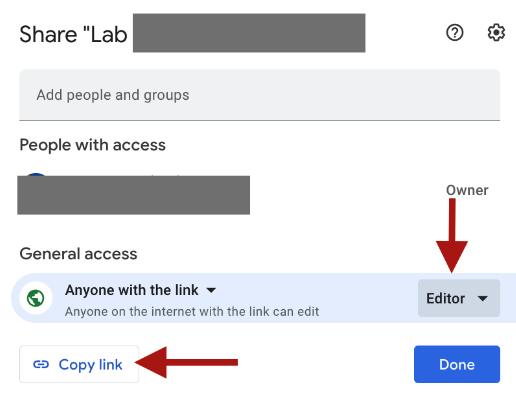

---
## Part VI. All Done, Congrats!

Today you've not only learned about null hypothesis significance testing (NHST), but you've also learned how to write some Python code. High five!

<img src="https://live.staticflickr.com/3471/3904325807_8ab0190152_b.jpg" alt="High-five!" width="300"/>

["High-five!"](https://live.staticflickr.com/3471/3904325807_8ab0190152_b.jpg) by Nick J Webb is licensed under CC BY 2.0